In [1]:
from myutils import plot, imshow
from src import *

In [3]:
# for m in ('di', 'spade'):
#     for d in np.arange(0, 101, 2):
#         c = Estimation.FromRaw(np.load(rf'__raw__\noisy\{m}_5px\{m}_5px_f0.2_d{int(d)}_raw.npy'), 
#                                MetaData(m.upper(), 0.2, 'frequency', 5*DMD.PIXEL_SIZE/2, int(d), 
#                                         timestamp=np.load(rf'__raw__\noisy\{m}_5px\{m}_5px_f0.2_d{int(d)}_timestamp.npy')))
    
#         c.savez(rf'__estimates__\noisy\{m}_5px')

In [ ]:
raise

In [1]:
from src import *
from src.core import _Share
from myutils import *
from scipy.special import erf, erfc

from src.fisherinfo import FrequencyCFI

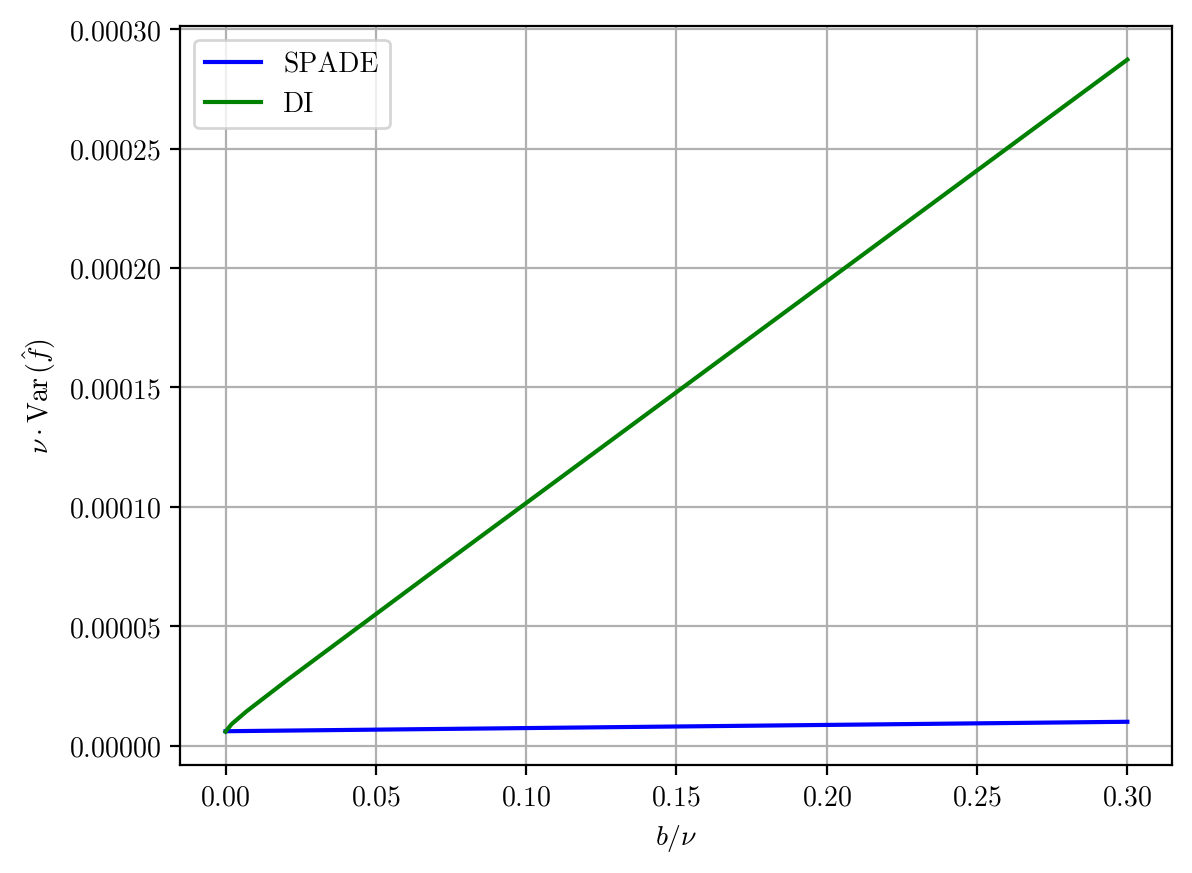

In [2]:
dicfi =  lambda b: FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 4.6])
spadecfi =  lambda b: FrequencyCFI(BiSPADE).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b])

b = np.linspace(1e-10, 0.3, 300)
di = 1/np.array([dicfi(_b) for _b in b])
spade = 1/np.array([spadecfi(_b) for _b in b])

plot(b, (spade), xlabel=r'$b/{\nu}$', label='SPADE')
plot(b, (di), ylabel=r'$\nu\cdot{\rm Var}\,(\hat{f})$', label='DI')
# axline(di[0])

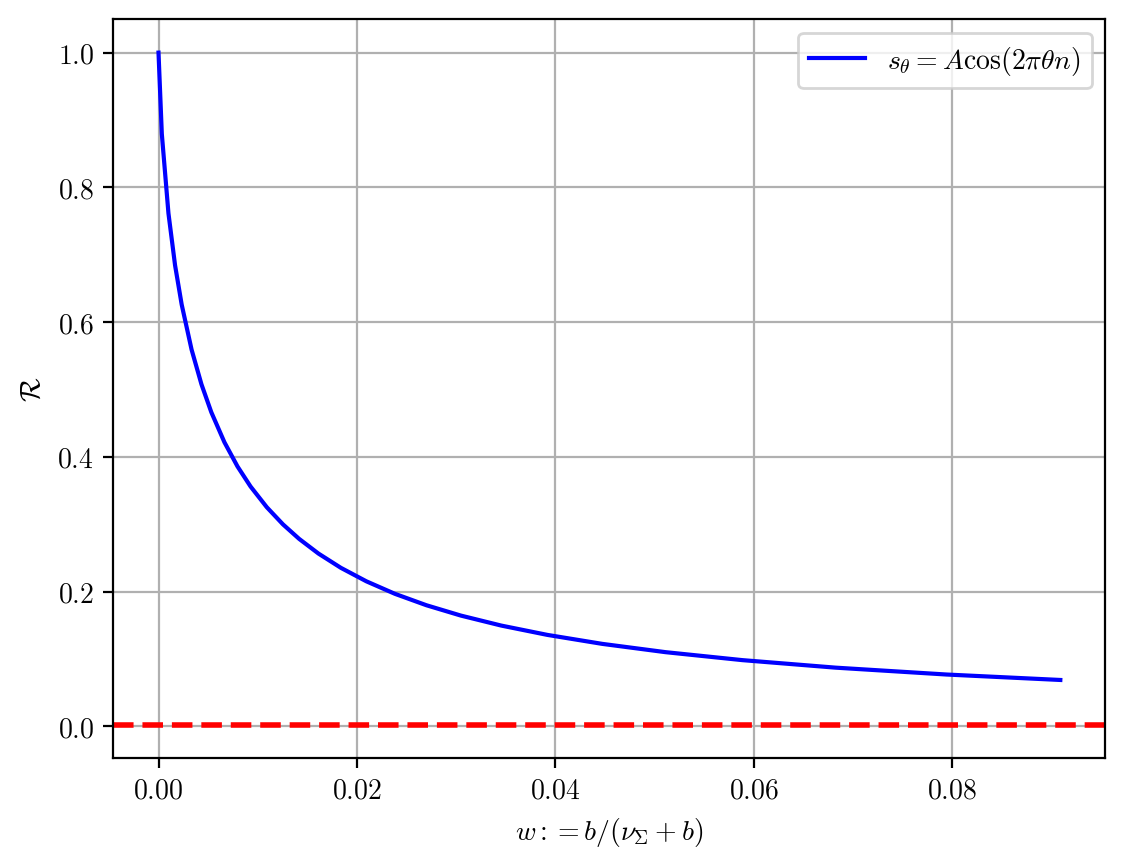

In [29]:
dicfi =  lambda b: FrequencyCFI(DI).cal(0.2, 0.01*DMD.PIXEL_SIZE/2, [b, 4.6])
spadecfi =  lambda b: FrequencyCFI(BiSPADE).cal(0.2, 0.01*DMD.PIXEL_SIZE/2, [b])

b = np.linspace(1e-10, 0.1, 300)
ratio = np.array([dicfi(_b) / spadecfi(_b) for _b in b])

plot((b/(1+b)), (ratio), ylabel=r'$\mathcal{R}$', xlabel=r'$w:={b}/{(\nu_{\Sigma}+b)}$', label=r'$s_\theta = A\cos(2\pi\theta n)$')
axline(1 / (2*sqrt(pi)*_Share.SIGMA))

In [4]:
spade_pn = LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{0}.npz').photons.mean()
di_pn = LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{0}.npz').photons.mean()
(spade_pn, di_pn)

(72.33684699999999, 433.01431799999995)

In [5]:
spade_f = [(LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{d}.npz').estimates_a).var(ddof=1) * spade_pn for d in np.arange(0, 101, 2)]
di_f = [(LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{d}.npz').estimates_a).var(ddof=1) * di_pn for d in np.arange(0, 101, 2)]

In [6]:
spade_b = [(LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{d}.npz').background).mean() for d in np.arange(0, 101, 2)]
di_b = [(LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{d}.npz').background).mean() for d in np.arange(0, 101, 2)]

spade_b = qCMOS.convert2photons(np.array(spade_b)) / spade_pn
di_b = qCMOS.convert2photons(np.array(di_b)) / di_pn

In [13]:
from scipy.interpolate import interp1d

In [16]:
spade_interp = interp1d(spade_b, spade_f)
di_interp = interp1d(di_b, di_f)

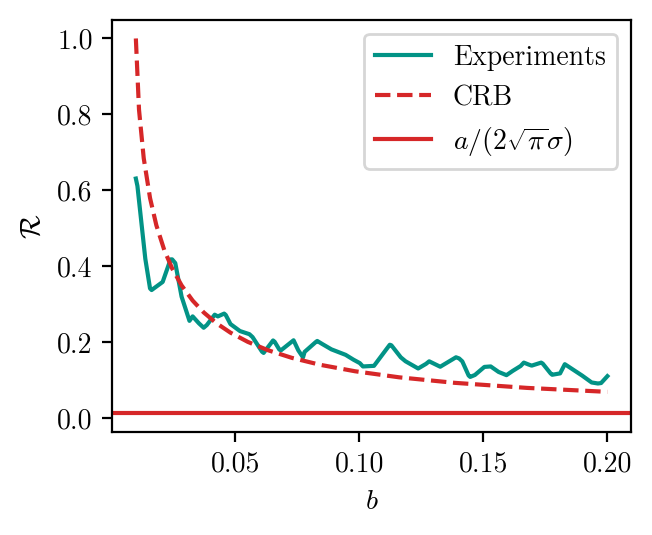

In [101]:
b = np.linspace(0.01, 0.2, 300)
plt.figure(figsize=(8.5  / 2.54, 8.5  / 2.54 * 0.8))
plt.plot(b, spade_interp(b) / di_interp(b), color='#029386', label='Experiments')
plt.plot(b, ratio, '--', color='#d62728', label='CRB')

plt.axhline(4.6 / (2*sqrt(pi)*103), c='#d62728', linestyle='-', label=r'$a/({2\sqrt{\pi}\sigma})$')

plt.xlabel(r'$b$')
plt.ylabel(r'$\mathcal {R}$')

plt.grid(False)
plt.legend()
plt.savefig('noisy.pdf')
plt.show()